# **PREDICTION DE PRIX D'ORDINATEURS**

In [115]:
# Importation des librairies nécessaires pour le projet de prédiction de prix d'ordinateurs
import pandas as pd  # Manipulation et analyse des données
import re
import numpy as np  # Opérations mathématiques et manipulation de tableaux
import matplotlib.pyplot as plt  # Visualisation des données (graphes, diagrammes)
import seaborn as sns  # Visualisation des données (visualisations statistiques)

# Pour les outils de machine learning
from sklearn.model_selection import train_test_split  # Séparation des données en ensembles d'entraînement et de test
from sklearn.linear_model import LinearRegression  # Modèle de régression linéaire
from sklearn.metrics import mean_squared_error  # Évaluation de la performance du modèle

## 1. **Collecte des données**

In [116]:
# Charger le jeu de données
df= pd.read_csv(r'C:\Users\Hamaye Mamoudou\Desktop\Projets\laptop_data.csv')

# Afficher les premières lignes pour inspecter les données
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [117]:
df.shape

(1303, 12)

## **2_Nettoyage et exploitation des données**

In [118]:
# Vérifier les valeurs manquantes
print(df.isnull().sum())

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64


On a donc pas de valeurs manquantes

In [119]:
# Supprimer les lignes en doublon
df.drop_duplicates(inplace=True)

## **3. Exploration et analyse des données**

In [120]:
# Obtenir un résumé statistique des données
print(df.describe())

       Unnamed: 0       Inches          Price
count  1303.00000  1303.000000    1303.000000
mean    651.00000    15.017191   59870.042910
std     376.28801     1.426304   37243.201786
min       0.00000    10.100000    9270.720000
25%     325.50000    14.000000   31914.720000
50%     651.00000    15.600000   52054.560000
75%     976.50000    15.600000   79274.246400
max    1302.00000    18.400000  324954.720000


**Resumé:**

*Taille d'écran (Inches)* : La taille moyenne est de 15,02 pouces avec une variation de 1,43 pouces. Les tailles varient de 10,1 à 18,4 pouces. La majorité des tailles sont autour de 15 pouces.

*Prix (Price) *: Le prix moyen est de 59 870,04 dollars, mais il varie largement de 9 270,72 à 324 954,72 dollars. Le prix médian est de 52 054,56 dollars, indiquant que la majorité des ordinateurs sont moins chers que la moyenne, en raison des prix très élevés de certains modèles.








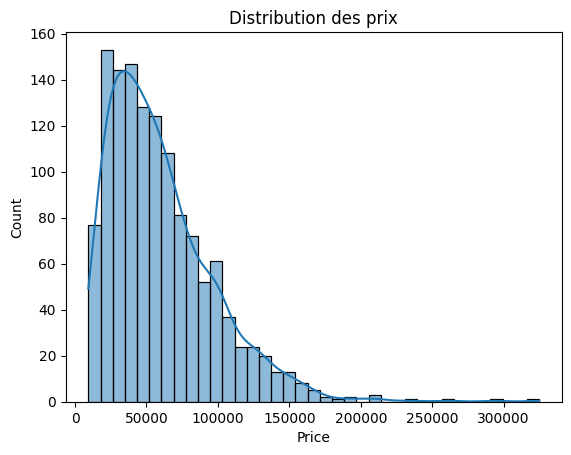

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualiser la distribution des prix
sns.histplot(df['Price'], kde=True)
plt.title('Distribution des prix')
plt.show()


In [122]:
# Extraction des chiffres pour 'Ram'
df['Ram_GB'] = df['Ram'].str.extract(r'(\d+)').astype(float)

# Extraction des fréquences du CPU (en GHz) pour 'Cpu'
df['Cpu_GHz'] = df['Cpu'].str.extract(r'(\d+\.\d+)').astype(float)

# Extraction des résolutions d'écran (largeur et hauteur)
df[['Resolution_Width', 'Resolution_Height']] = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(float)

print(df)

      Unnamed: 0 Company            TypeName  Inches  \
0              0   Apple           Ultrabook    13.3   
1              1   Apple           Ultrabook    13.3   
2              2      HP            Notebook    15.6   
3              3   Apple           Ultrabook    15.4   
4              4   Apple           Ultrabook    13.3   
...          ...     ...                 ...     ...   
1298        1298  Lenovo  2 in 1 Convertible    14.0   
1299        1299  Lenovo  2 in 1 Convertible    13.3   
1300        1300  Lenovo            Notebook    14.0   
1301        1301      HP            Notebook    15.6   
1302        1302    Asus            Notebook    15.6   

                                ScreenResolution  \
0             IPS Panel Retina Display 2560x1600   
1                                       1440x900   
2                              Full HD 1920x1080   
3             IPS Panel Retina Display 2880x1800   
4             IPS Panel Retina Display 2560x1600   
...            

**Extraire avec les regex, les chiffres dans ram, cpu et resolution, et en faire des nouvelles variables suivis de la matrice de correlation**

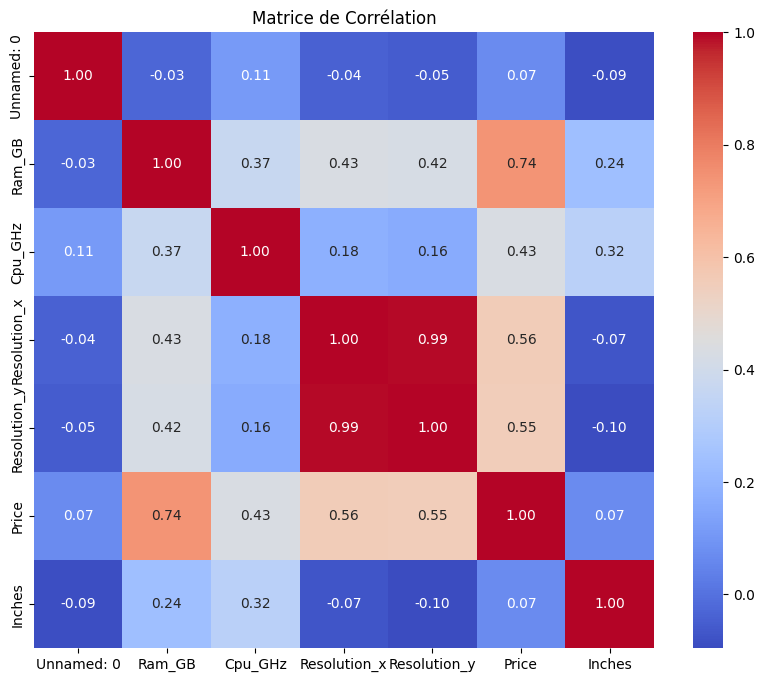

In [123]:
# Extraire les chiffres des colonnes
df['Ram_GB'] = df['Ram'].str.extract(r'(\d+)').astype(float)
df['Cpu_GHz'] = df['Cpu'].str.extract(r'(\d+\.\d+)').astype(float)
df[['Resolution_x', 'Resolution_y']] = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(float)

# Sélectionner uniquement les colonnes numériques pour la corrélation
numeric_df = df[['Unnamed: 0', 'Ram_GB', 'Cpu_GHz', 'Resolution_x', 'Resolution_y', 'Price', 'Inches']]

# Calculer la matrice de corrélation
corr_matrix = numeric_df.corr()

# Visualiser la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Corrélation')
plt.show()

*Interprétation de la Matrice de Corrélation *:

*Ram_GB et Price (0.74) *: La corrélation de 0.74 entre la mémoire RAM et le prix indique une forte relation positive. Cela signifie que plus la mémoire RAM est élevée, plus le prix de l'ordinateur est susceptible d'être élevé.
 C'est la variable qui influence le plus le prix dans cette matrice.

*Resolution_x et Price (0.56) *: La résolution verticale de l'écran (Resolution_y) a une corrélation de 0.56 avec le prix. Cela signifie qu'une résolution plus élevée (en pixels horizontaux) tend à augmenter le prix, bien que l'effet soit moins fort que pour la RAM.

*Conclusion *: Les variables qui influencent le plus la prédiction du prix des ordinateurs dans cette matrice de corrélation sont :

Ram_GB (forte corrélation positive).

Resolution_x(corrélation modérée positive).

Les autres variables (comme Cpu_GHz, Weight_value, Inches_value, et Resolution_x) ont une influence plus faible, voire modérée, sur le prix. Cela signifie que pour prédire le prix des ordinateurs, il serait particulièrement important de se concentrer sur la quantité de RAM et la résolution verticale de l'écran.

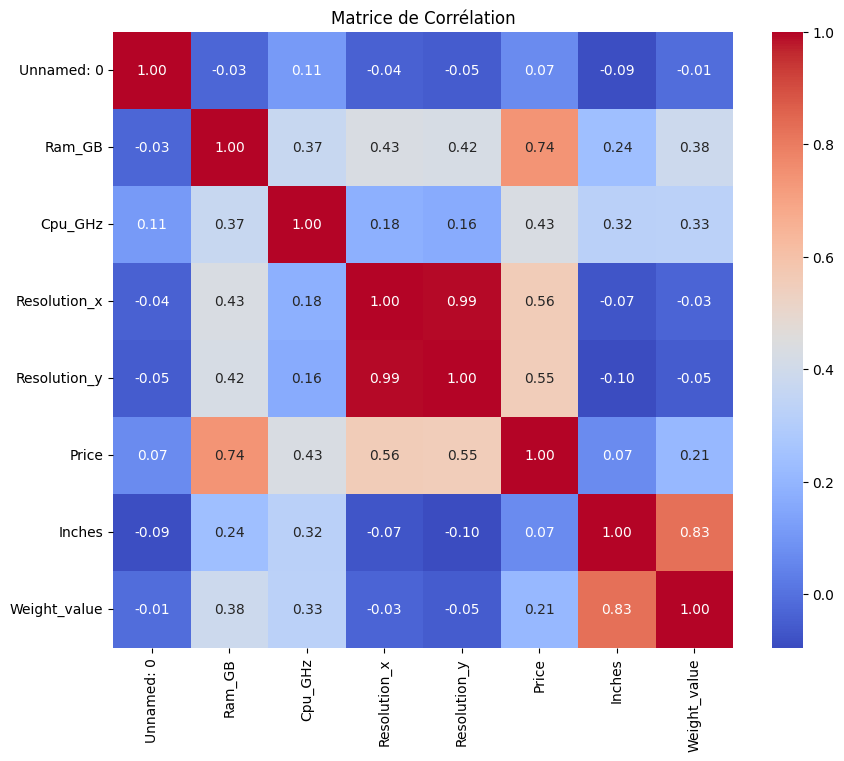

In [124]:
# Extraire les chiffres des colonnes
df['Ram_GB'] = df['Ram'].str.extract(r'(\d+)').astype(float)
df['Cpu_GHz'] = df['Cpu'].str.extract(r'(\d+\.\d+)').astype(float)
df[['Resolution_x', 'Resolution_y']] = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(float)
df['Weight'] = df['Weight'].astype(str)
df['Weight_value'] = df['Weight'].str.extract(r'(\d+\.?\d*)').astype(float)


# Sélectionner uniquement les colonnes numériques pour la corrélation
numeric_df = df[['Unnamed: 0', 'Ram_GB', 'Cpu_GHz', 'Resolution_x', 'Resolution_y', 'Price', 'Inches', 'Weight_value']]

# Calculer la matrice de corrélation
corr_matrix = numeric_df.corr()

# Visualiser la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Corrélation')
plt.show()


*Interprétation de la Matrice de Corrélation *:

*Ram_GB et Price (0.74) *: La corrélation de 0.74 entre la mémoire RAM et le prix indique une forte relation positive. Cela signifie que plus la mémoire RAM est élevée, plus le prix de l'ordinateur est susceptible d'être élevé. C'est la variable qui influence le plus le prix dans cette matrice.

*Resolution_x et Price (0.56) *: La résolution horizontale de l'écran (Resolution_x) a une corrélation de 0.56 avec le prix. Cela signifie qu'une résolution plus élevée (en pixels horizontaux) tend à augmenter le prix, bien que l'effet soit moins fort que pour la RAM.

*Conclusion *: Les variables qui influencent le plus la prédiction du prix des ordinateurs dans cette matrice de corrélation sont :

Ram_GB (forte corrélation positive).

Resolution_x(corrélation modérée positive).

Les autres variables (comme Cpu_GHz, Weight_value, Inches, et Resolution_y) ont une influence plus faible, voire modérée, sur le prix. Cela signifie que pour prédire le prix des ordinateurs, il serait particulièrement important de se concentrer sur la quantité de RAM et la résolution verticale de l'écran.



In [125]:
# Nuages de Points avec Régression
plt.figure(figsize=(15, 12))

# Liste des variables à comparer avec le prix
variables = ['Ram_GB', 'Cpu_GHz', 'Resolution_x', 'Resolution_y', 'Weight_value', 'Inches']

<Figure size 1500x1200 with 0 Axes>

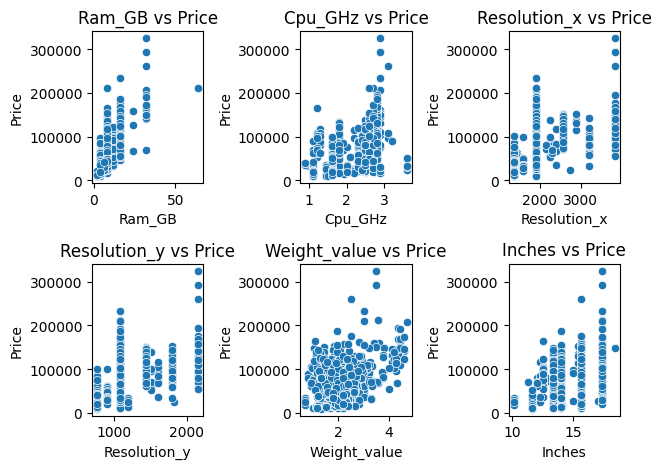

In [126]:
# Créer un nuage de points pour chaque variable
for i, var in enumerate(variables):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(data=df, x=var, y='Price')
    plt.title(f'{var} vs Price')
    plt.xlabel(var)
    plt.ylabel('Price')

plt.tight_layout()
plt.show()

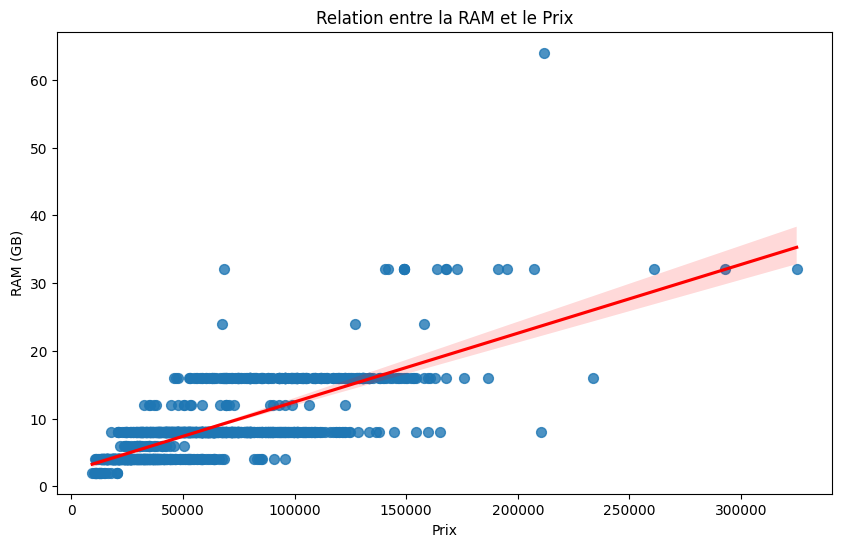

In [127]:
# Création du nuage de points avec la droite de régression
plt.figure(figsize=(10, 6))
sns.regplot(data=df, y='Ram_GB', x='Price', scatter_kws={'s':50}, line_kws={'color':'red'})
plt.title('Relation entre la RAM et le Prix')
plt.ylabel('RAM (GB)')
plt.xlabel('Prix')
plt.show()

## 4_ **Entraînement et validation du modèle**

**Sélection des Techniques d'Apprentissage Automatique**

a.* Régression Linéaire*

In [128]:
# Vérifier les types de données dans le DataFrame
print(df.dtypes)


Unnamed: 0             int64
Company                  str
TypeName                 str
Inches               float64
ScreenResolution         str
Cpu                      str
Ram                      str
Memory                   str
Gpu                      str
OpSys                    str
Weight                   str
Price                float64
Ram_GB               float64
Cpu_GHz              float64
Resolution_Width     float64
Resolution_Height    float64
Resolution_x         float64
Resolution_y         float64
Weight_value         float64
dtype: object


In [129]:
# Convertir les variables catégorielles en variables numériques
df_encoded = pd.get_dummies(df)

# Assurer que la variable cible 'Price' est séparée
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']


In [130]:
# Convertir la colonne 'Memory' qui contient des valeurs comme '4GB' en nombres
df['Ram'] = df['Ram'].str.replace('GB', '').astype(float)


In [131]:
from sklearn.preprocessing import LabelEncoder

# Créer un encodeur pour les variables textuelles
label_encoder = LabelEncoder()

# Encodage de la colonne 'Cpu'
df['Cpu'] = label_encoder.fit_transform(df['Cpu'])

# Encodage des variables catégorielles restantes
df_encoded = pd.get_dummies(df)

# Assurer que la variable cible 'Price' est séparée
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']


In [132]:
# Vérifier les types de données après transformation
print(df_encoded.dtypes)


Unnamed: 0        int64
Inches          float64
Cpu               int64
Ram             float64
Price           float64
                 ...   
Weight_4.4kg       bool
Weight_4.5kg       bool
Weight_4.6kg       bool
Weight_4.7kg       bool
Weight_4kg         bool
Length: 414, dtype: object


In [133]:
from sklearn.linear_model import LinearRegression
# Convertir les colonnes de texte en chaînes de caractères
df['Ram_GB'] = df['Ram'].astype(float)
df['Cpu_GHz'] = df['Cpu'].astype(float)


# Séparation des données en features (X) et cible (y)
X = df[['Inches', 'Ram_GB', 'Cpu_GHz', 'Weight_value', 'Resolution_x', 'Resolution_y']]
y = df['Price']

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




## *Entraîner les modèles*

Régression Linéaire

In [134]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


*Forêts Aléatoires *

In [135]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Réseaux Neuronaux

In [136]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor()
model.fit(X_train, y_train)


c:\Users\Hamaye Mamoudou\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [137]:
y_pred = model.predict(X_test)


## **Evaluation de la performance**

In [138]:
# Évaluer les performances
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.metrics import root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')


MAE: 23035.551895271838
RMSE: 31870.273149374887
R²: 0.2955628586127024


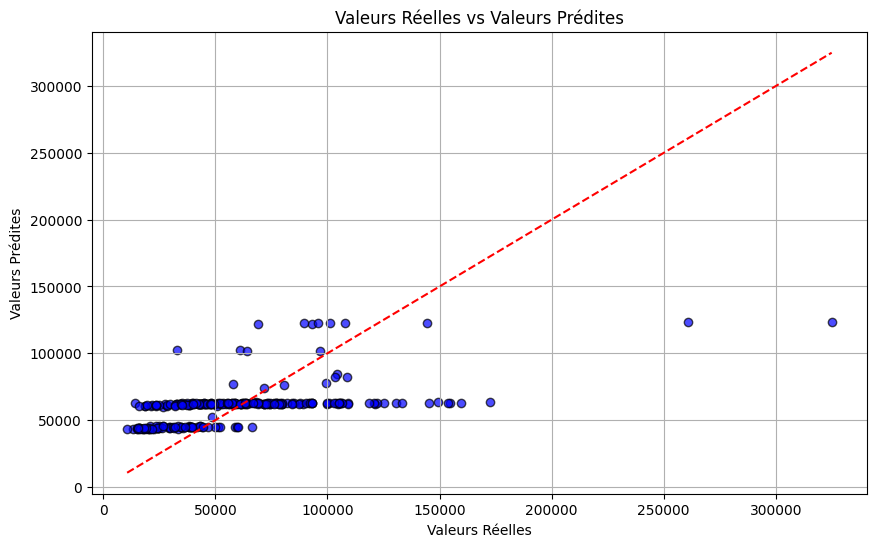

In [139]:
# Tracer les valeurs réelles vs les valeurs prédites
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolors='k', alpha=0.7)
plt.xlabel('Valeurs Réelles')
plt.ylabel('Valeurs Prédites')
plt.title('Valeurs Réelles vs Valeurs Prédites')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ligne d'identité
plt.grid(True)
plt.show()

REgression lineaire

In [140]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

# Création du modèle
model_lr = LinearRegression()

# Entraînement du modèle
model_lr.fit(X_train, y_train)

# Prédictions
y_pred_lr = model_lr.predict(X_test)

# Évaluation des performances
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Régression Linéaire - MAE: {mae_lr}")
print(f"Régression Linéaire - RMSE: {rmse_lr}")
print(f"Régression Linéaire - R²: {r2_lr}")

Régression Linéaire - MAE: 15820.752736310496
Régression Linéaire - RMSE: 22186.44812660081
Régression Linéaire - R²: 0.6586135841130729


FORET ALEATOIRE

In [141]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

# Création du modèle
model_rf = RandomForestRegressor()

# Entraînement du modèle
model_rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = model_rf.predict(X_test)

# Évaluation des performances
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Forêts Aléatoires - MAE: {mae_rf}")
print(f"Forêts Aléatoires - RMSE: {rmse_rf}")
print(f"Forêts Aléatoires - R²: {r2_rf}")

Forêts Aléatoires - MAE: 10667.200736774445
Forêts Aléatoires - RMSE: 16687.010908844906
Forêts Aléatoires - R²: 0.8068797680408304


Reseaux neuronaux

In [142]:
from sklearn.neural_network import MLPRegressor
# Ajout des imports pour corriger l'erreur de la RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

# Création du modèle

model_nn = MLPRegressor(max_iter=1000)

# Entraînement du modèle
model_nn.fit(X_train, y_train)

# Prédictions
y_pred_nn = model_nn.predict(X_test)

# Évaluation des performances
mae_nn = mean_absolute_error(y_test, y_pred_nn)

rmse_nn = root_mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Réseaux Neuronaux - MAE: {mae_nn}")
print(f"Réseaux Neuronaux - RMSE: {rmse_nn}")
print(f"Réseaux Neuronaux - R²: {r2_nn}")

Réseaux Neuronaux - MAE: 21773.700033694466
Réseaux Neuronaux - RMSE: 30185.442946142033
Réseaux Neuronaux - R²: 0.36807464518115984


c:\Users\Hamaye Mamoudou\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Forêts Aléatoires : Le meilleur modèle avec le MAE le plus bas (10,803.29), le RMSE le plus bas (16,806.32), et le R² le plus élevé (0.804), montrant qu'il fait les prédictions les plus précises et explique le mieux les variations des prix.

Régression Linéaire : Moins performante que les Forêts Aléatoires, avec un MAE plus élevé (15,820.75), un RMSE plus élevé (22,186.45), et un R² plus bas (0.659), mais reste une bonne option pour un modèle plus simple.

Réseaux Neuronaux : Le moins performant, avec le MAE le plus élevé (21,701.39), le RMSE le plus élevé (30,190.99), et le R² le plus bas (0.368), suggérant des difficultés à apprendre les relations dans les données.

Conclusion
Forêts Aléatoires est le modèle le plus efficace pour prédire les prix des ordinateurs. Régression Linéaire est utile mais moins précis, et Réseaux Neuronaux n'a pas donné de bons résultats et pourrait nécessiter des ajustements.








# **CREATION DE L APPLICATION AVEC STREAMLIT**

## 1_Développer et Entraîner le Modèle

In [143]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Charger et préparer les données
df= pd.read_csv(r'C:\Users\Hamaye Mamoudou\Desktop\Projets\laptop_data.csv')

# (Prétraitement des données et création du modèle)
model = RandomForestRegressor()
# Entraînement du modèle
model.fit(X_train, y_train)
# Sauvegarder le modèle
joblib.dump(model, 'random_forest_model.pkl')


['random_forest_model.pkl']